In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set styling
sns.set_theme(style="whitegrid")

# Load data using relative path
df = pd.read_csv(r"C:\Users\msii\Documents\bigdata\Iris_dataset.csv")

# Display sample rows
print("--- First 5 Rows ---")
print(df.head())

# Report shape, columns, and data types
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("--- Column Types and Info ---")
df.info()

--- First 5 Rows ---
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa
Dataset Shape: 150 rows, 5 columns

--- Column Types and Info ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [14]:
# Check missing values
print("--- Missing Values Count ---")
print(df.isnull().sum())

# Check duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows Count: {duplicates}")
if duplicates > 0:
    print("\n--- Duplicate Row Details ---")
    print(df[df.duplicated(keep=False)])

--- Missing Values Count ---
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Duplicate Rows Count: 1

--- Duplicate Row Details ---
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
101            5.8           2.7            5.1           1.9  Iris-virginica
142            5.8           2.7            5.1           1.9  Iris-virginica


In [15]:
# Class counts
print("--- Species Distribution ---")
print(df['Species'].value_counts())

# Summary statistics grouped by species
print("\n--- Grouped Statistics by Species ---")
print(df.groupby('Species').agg(['count', 'mean', 'median', 'std', 'min', 'max']))

--- Species Distribution ---
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

--- Grouped Statistics by Species ---
                SepalLengthCm                                   SepalWidthCm  \
                        count   mean median       std  min  max        count   
Species                                                                        
Iris-setosa                50  5.006    5.0  0.352490  4.3  5.8           50   
Iris-versicolor            50  5.936    5.9  0.516171  4.9  7.0           50   
Iris-virginica             50  6.588    6.5  0.635880  4.9  7.9           50   

                                         ... PetalLengthCm                 \
                  mean median       std  ...        median       std  min   
Species                                  ...                                
Iris-setosa      3.428    3.4  0.379064  ...          1.50  0.173664  1.0   
Iris-versicolor  2.770    2.8  0.313798  ..

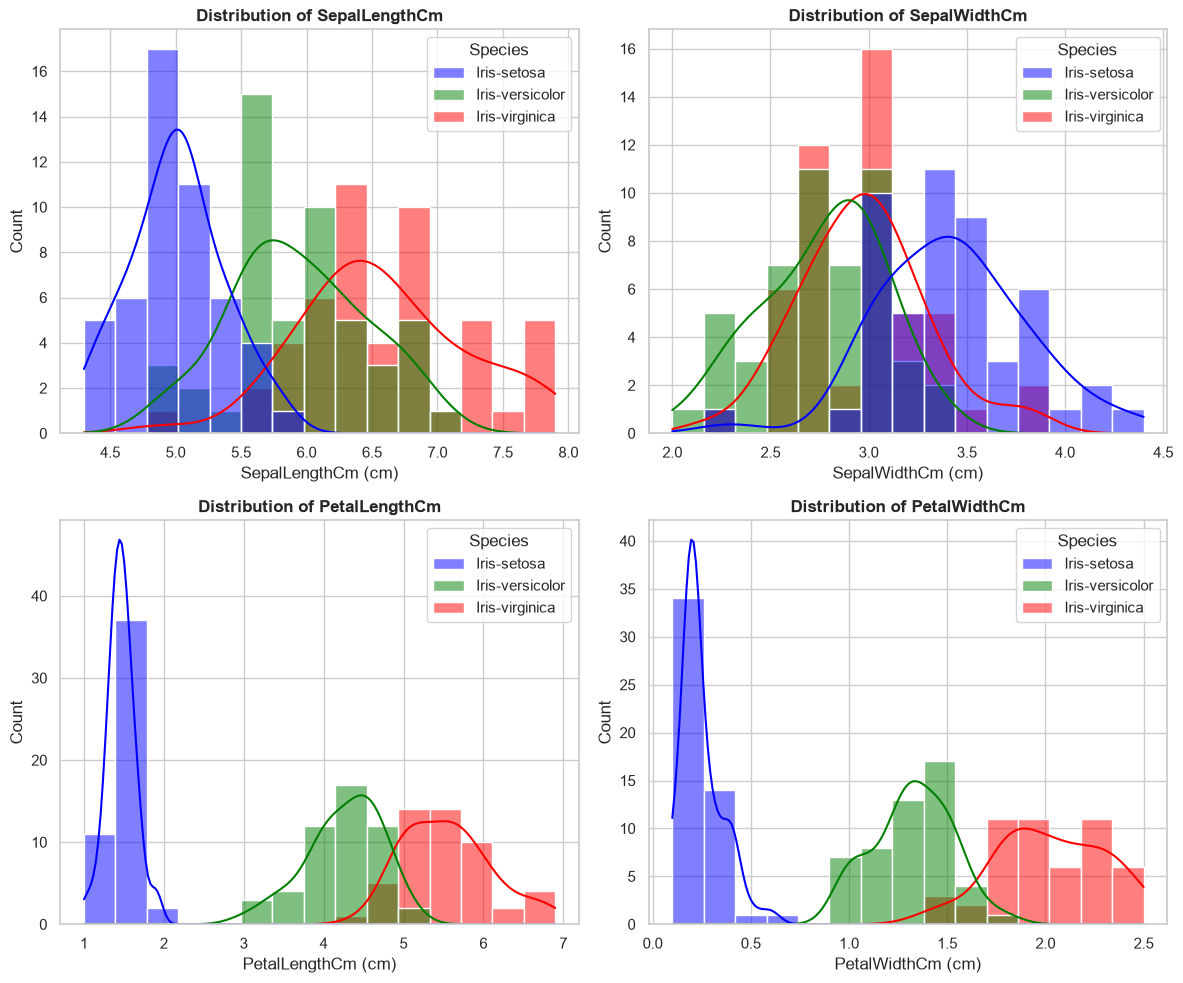

In [13]:
# Feature Distributions across Species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
palette = {'Iris-setosa': 'blue', 'Iris-versicolor': 'green', 'Iris-virginica': 'red'}

for ax, feature in zip(axes.flatten(), features):
    sns.histplot(data=df, x=feature, hue='Species', kde=True, ax=ax, palette=palette, bins=15, alpha=0.5)
    ax.set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{feature} (cm)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

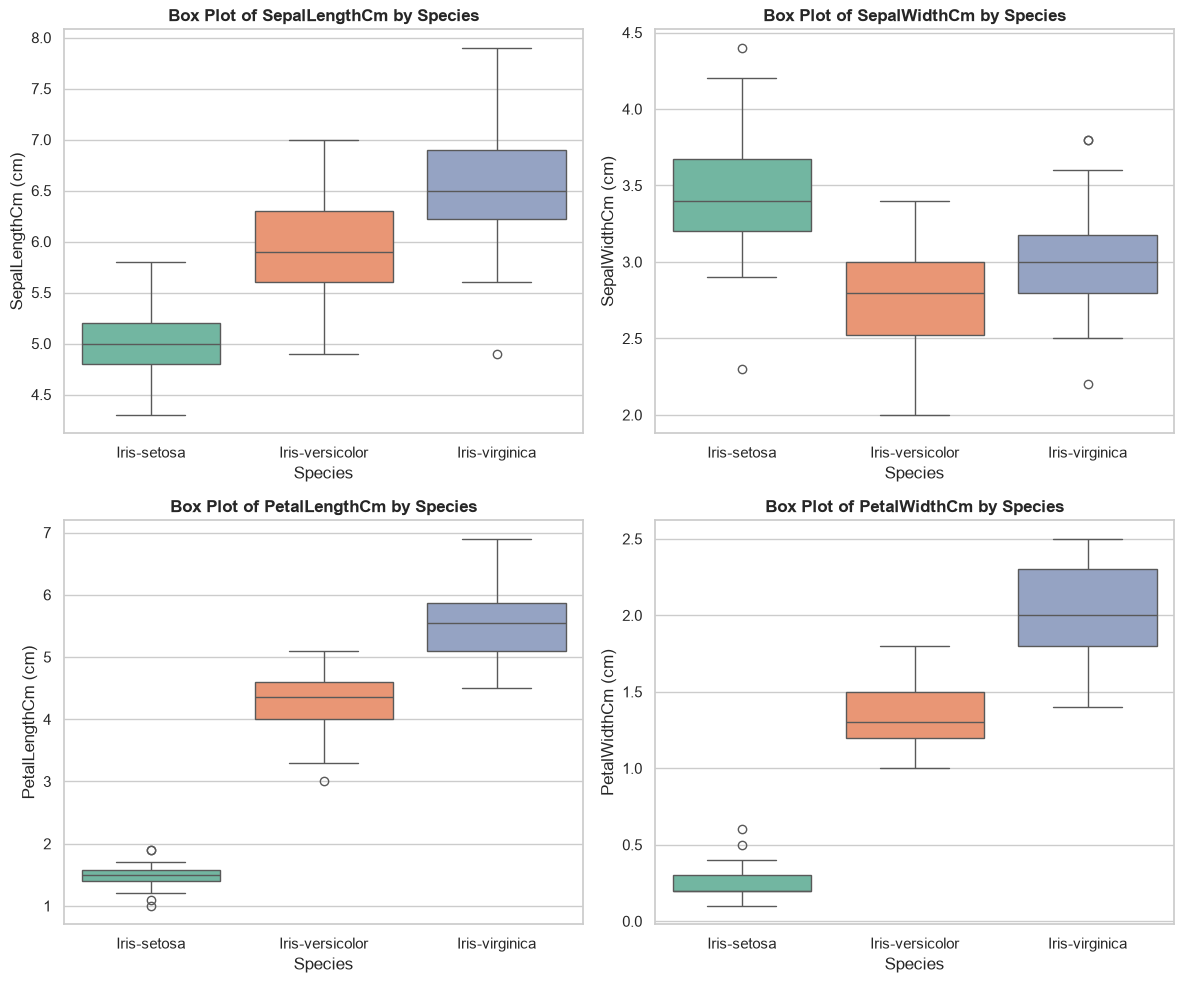

In [11]:
# Box plots to examine spread and outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='Species', y=feature, hue='Species', legend=False, ax=ax, palette='Set2')
    ax.set_title(f'Box Plot of {feature} by Species', fontsize=12, fontweight='bold')
    ax.set_xlabel('Species')
    ax.set_ylabel(f'{feature} (cm)')

plt.tight_layout()
plt.show()

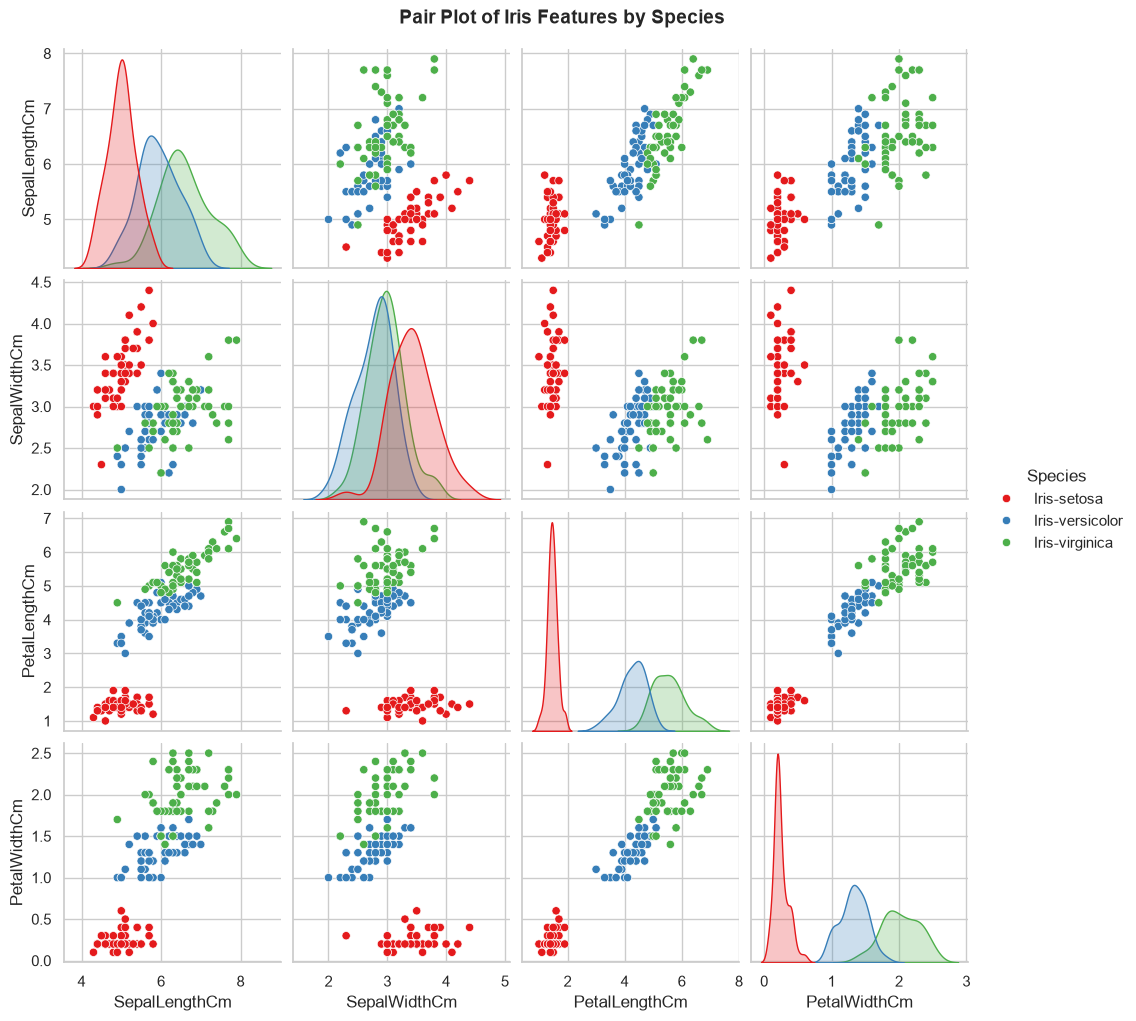

In [9]:
# Pairplot for pairwise feature relationships
sns.pairplot(df, hue='Species', palette='Set1', height=2.5)
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02, fontsize=14, fontweight='bold')
plt.show()

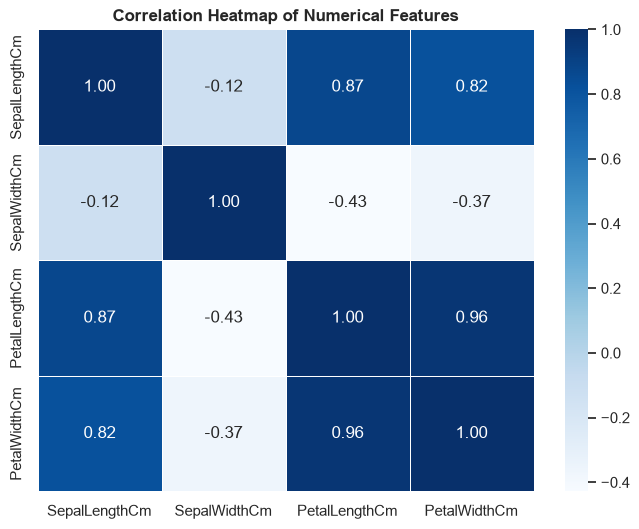

In [10]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.drop(columns=['Species'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=12, fontweight='bold')
plt.show()